# WSI Visualization in LazySlide

LazySlide implements different plotting functions to showcase different parts of `WSIData`. In this tutorial, we will explore how to visualize whole slide images (WSI) using LazySlide. You will learn how to display:
- Tissue contours
- Tile grids
- Feature projections
- Pathological annotations

WSI visualization is crucial for interpreting complex tissue structures, identifying pathological regions, interpreting deep-learning features and facilitating efficient analysis in digital pathology workflows. This guide will help you understand the capabilities of LazySlide for easy and interactive WSI visualization.

/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  return _bootstrap._gcd_import(name[level:], package, level)


/home/runner/work/lazyslide-tutorials/lazyslide-tutorials/.venv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


/home/runner/work/lazyslide-tutorials/lazyslide-tutorials/.venv/lib/python3.12/site-packages/wsidata/io/_wsi.py:136: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = read_zarr(store)


/home/runner/work/lazyslide-tutorials/lazyslide-tutorials/.venv/lib/python3.12/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


WSI: /home/runner/.cache/huggingface/hub/datasets--RendeiroLab--LazySlide-data/snapshots/9644d886889040fa10e757d912f249bbf936a979/GTEX-1117F-0526.svs
Reader: openslide
Dimensions: 19958×19919 (h×w), 3 Pyramids
Pixel physical size: 0.4942 MPP
SpatialData object, with associated Zarr store: /home/runner/.cache/huggingface/hub/datasets--RendeiroLab--LazySlide-data/snapshots/9644d886889040fa10e757d912f249bbf936a979/GTEX-1117F-0526.zarr
├── Images
│     └── 'wsi_thumbnail': DataArray[cyx] (3, 1996, 1992)
├── Shapes
│     ├── 'annotations': GeoDataFrame shape: (14, 5) (2D shapes)
│     ├── 'dl-tissue': GeoDataFrame shape: (2, 2) (2D shapes)
│     ├── 'tiles': GeoDataFrame shape: (253, 3) (2D shapes)
│     └── 'tissues': GeoDataFrame shape: (2, 2) (2D shapes)
└── Tables
      ├── 'resnet50_tiles': AnnData (253, 2048)
      └── 'uni2_tiles': AnnData (253, 1536)
with coordinate systems:
    ▸ 'global', with elements:
        wsi_thumbnail (Images), annotations (Shapes), dl-tissue (Shapes), tiles (Shapes), tissues (Shapes)
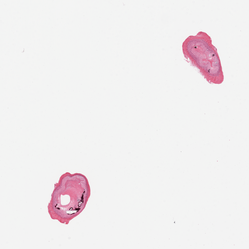

In [1]:
import lazyslide as zs

wsi = zs.datasets.gtex_artery()
wsi

## Visualize tissue

As we showed in previous tutorials, you can detect the tissue pieces with `pp.find_tissues`. Once you have the tissues detected, you can plot them. You will see both colored contours and id of tissues.

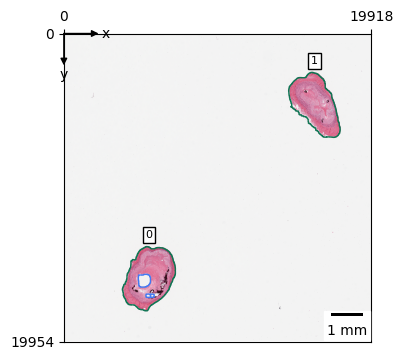

In [2]:
zs.pl.tissue(wsi)

If you want to zoom in to specific tissue, you can specify the tissue id.

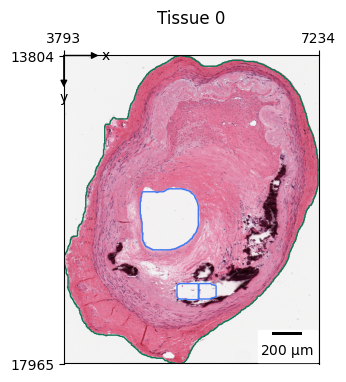

In [3]:
zs.pl.tissue(wsi, tissue_id=0)

You can see the tissue contour in green and holes in blue. Apart from showing a tissue piece, you can add a zoom view to highlight a specific region when plotting the tissue by using the `zoom` parameter.

It takes four values: `zoom=[xmin, xmax, ymin, ymax]` that define a rectangular region.

**How zoom values work:**
- **Values between 0-1**: Interpreted as fractions of the total image size
  - `zoom=[0.6, 0.9, 0.3, 0.6]` means from 60% to 90% horizontally and 30% to 60% vertically
- **Values > 1**: Interpreted as absolute pixel coordinates
  - `zoom=[1000, 2000, 500, 1500]` means from pixel 1000 to 2000 horizontally and pixel 500 to 1500 vertically

[!TIP]
Look at the corners of any plot - you'll see pixel coordinates displayed there. These numbers help you determine the exact pixel ranges for your zoom regions, making it easy to navigate to specific areas of interest in large WSI files.


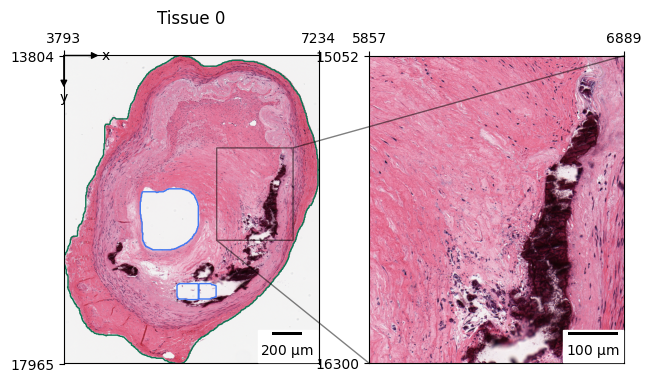

In [4]:
zs.pl.tissue(wsi, tissue_id=0, zoom=[0.6, 0.9, 0.3, 0.6])

You can also render all individual tissue pieces at once.

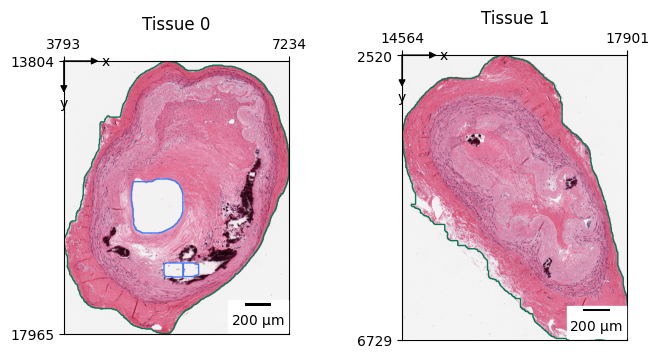

In [5]:
zs.pl.tissue(wsi, tissue_id="all")

## Visualize tiles

Apart from the `pl.tissues` function, you can also use `pl.tiles` to visualize the tiles (after we have performed tiling on the WSI with `pp.tile_tissues`).

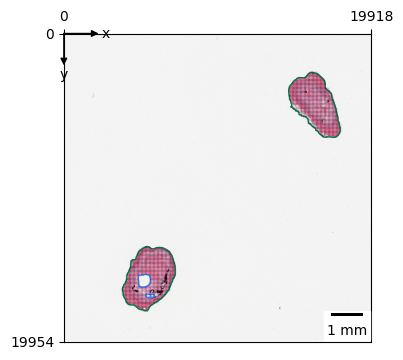

In [6]:
zs.pl.tiles(wsi)

By default, it will only display the tile grid on the tissues since the target object for the tiling is the detected tissue.

If not clear enough, you can also zoom in.

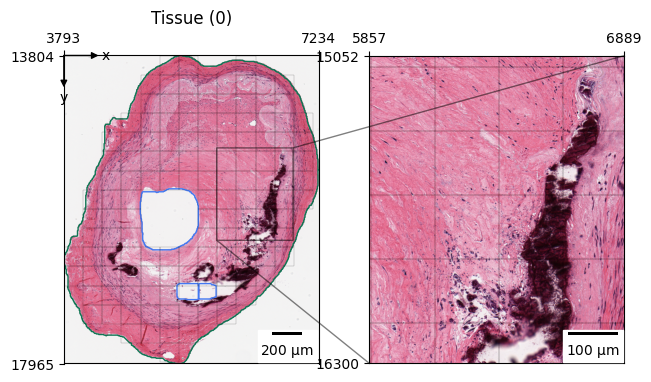

In [7]:
zs.pl.tiles(wsi, tissue_id=0, zoom=[0.6, 0.9, 0.3, 0.6])

Furthermore, we can project many features onto the tile visualization. These features are not informative of the tissue itself, but of the quality of the images. They can be used downstream for filtering out low-quality tiles.

In [8]:
wsi["tiles"].head()

,tile_id,tissue_id,geometry
0,0,0,"POLYGON ((4052 16394, 4052 16653, 3793 16653, ..."
1,1,0,"POLYGON ((4052 16653, 4052 16912, 3793 16912, ..."
2,2,0,"POLYGON ((4311 15617, 4311 15876, 4052 15876, ..."
3,3,0,"POLYGON ((4311 15876, 4311 16135, 4052 16135, ..."
4,4,0,"POLYGON ((4311 16135, 4311 16394, 4052 16394, ..."


In [9]:
zs.tl.tile_prediction(wsi, "pathprofilerqc", device="cpu")

PathProfiler/pathprofiler_patch_quality_(…):   0%|          | 0.00/44.9M [00:00<?, ?B/s]

Output()

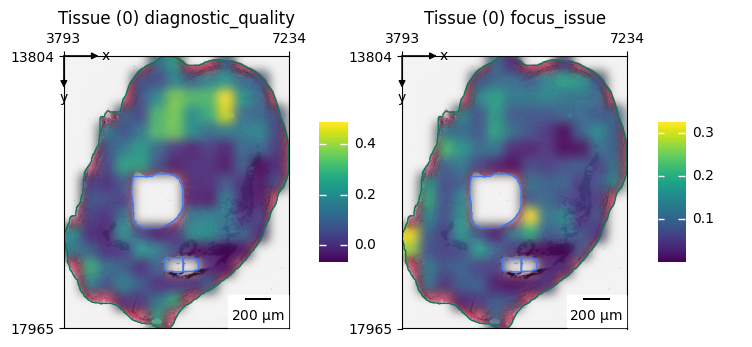

In [10]:
zs.pl.tiles(wsi, tissue_id=0, color=["diagnostic_quality", "focus_issue"], smooth=True)

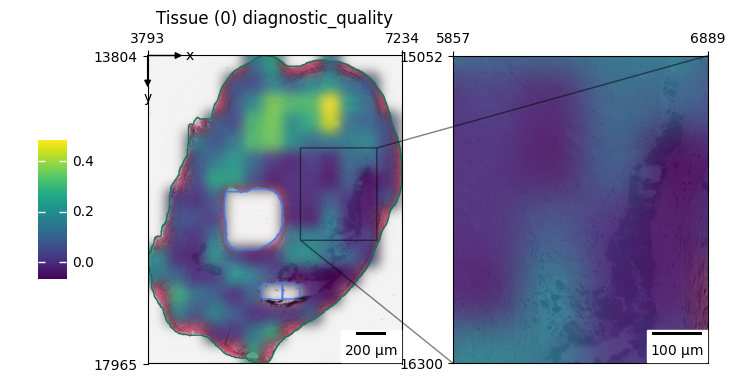

In [11]:
zs.pl.tiles(
    wsi, tissue_id=0, color="diagnostic_quality", zoom=[0.6, 0.9, 0.3, 0.6], smooth=True
)

We can also project deep-learning features onto the tiles of the tissue. In this example we have extracted features from the ResNet model. ResNet, short for Residual Network, is a widely used neural network architecture that uses "skip connections" to allow the training of much deeper and more accurate models, primarily for image recognition tasks.

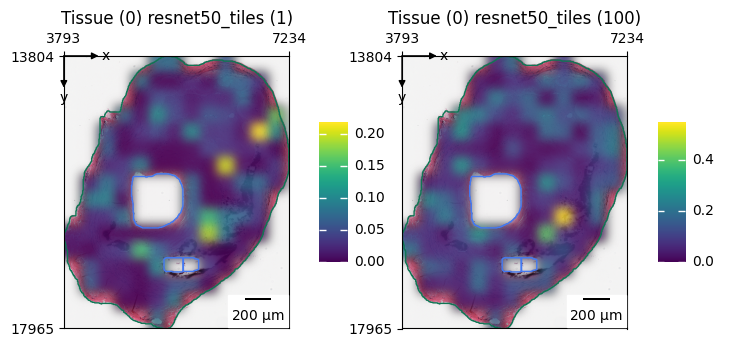

In [12]:
zs.pl.tiles(wsi, tissue_id=0, feature_key="resnet50", color=["1", "100"], smooth=True)

## Visualize annotations

If you have imported pathology annotations, they can also be visualized. These annotations are usually made by pathologists, using external tools like [QuPath](https://qupath.github.io/). They are very valuable, as they are made by experts and represent the ground truth.  Below are some example annotations imported for showcasing. We can visualize them with `zs.pl.annotations`.


In [13]:
wsi["annotations"].head()

,tissue_id,id,objectType,name,geometry
0,0,f56c25e5-ce21-4d42-bcda-b67b9fd98870,annotation,sclerosis,"POLYGON ((4631.5 16627, 4629 16628, 4594 16628..."
1,0,c799bbe2-5a08-467a-9e5d-6376b718cee8,annotation,sclerosis,"POLYGON ((4528 16331, 4527.67 16331.17, 4527 1..."
2,0,bcc06960-003b-43f0-9e88-496579dffd34,annotation,sclerosis,"POLYGON ((5598.73 17098.36, 5596 17102, 5594.8..."
3,0,e3ba7093-e973-424a-9c77-66caa03569fb,annotation,sclerosis,"POLYGON ((5964 17053, 5956 17055, 5954.2 17056..."
4,0,370d0dc5-f5d1-40d9-bce6-d47f63fc4cbc,annotation,sclerosis,"POLYGON ((5649 16849, 5652 16848, 5655 16848, ..."


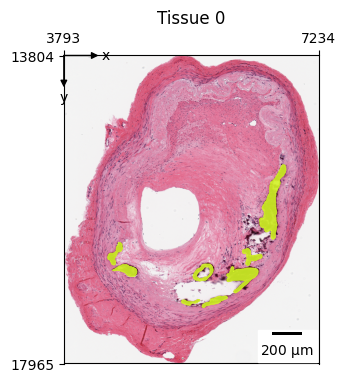

In [14]:
zs.pl.annotations(wsi, "annotations", tissue_id=0)

On top of that, you can also add labels onto the image.

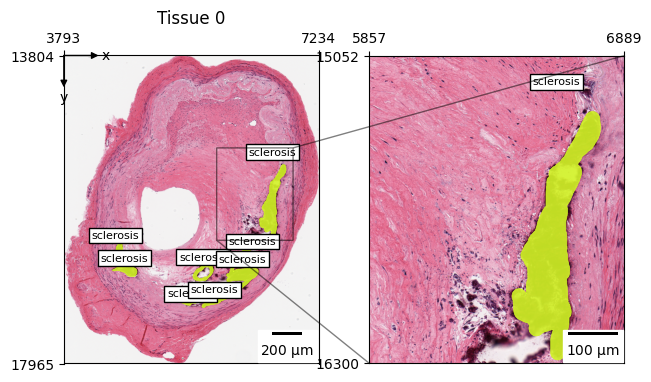

In [15]:
zs.pl.annotations(
    wsi, "annotations", tissue_id=0, label="name", zoom=[0.6, 0.9, 0.3, 0.6]
)

## Declarative visualization in LazySlide

Since `WSIData` extends from `SpatialData`, you may use `spatialdata-plot` to visualize the WSI. However, LazySlide implements a super fast and efficient plotting system to help visualize WSI from macro structures to single cells.

We start with an empty viewer, you will need to choose what to add on top of the visualization.

<Axes: >

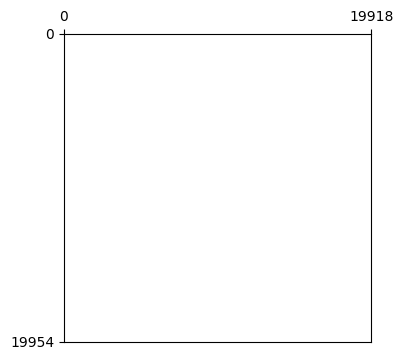

In [16]:
v = zs.pl.WSIViewer(wsi)
v.show()

In most situation, we need the slide image as the background.

<Axes: >

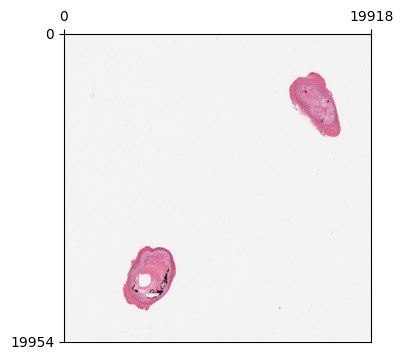

In [17]:
v.add_image()
v.show()

<Axes: >

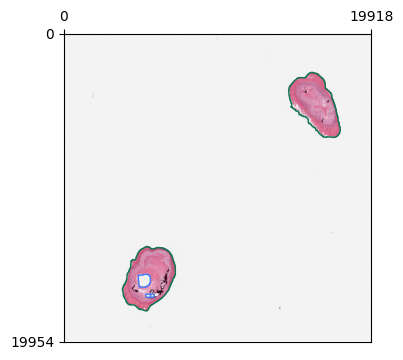

In [18]:
v.add_contours("tissues")
v.show()

<Axes: >

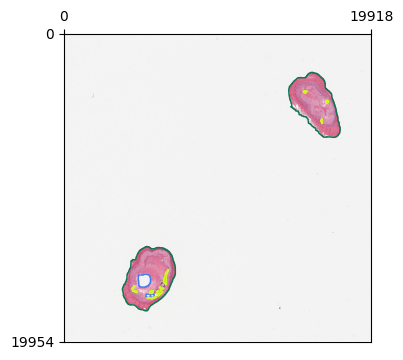

In [19]:
v.add_polygons("annotations")
v.show()

<Axes: >

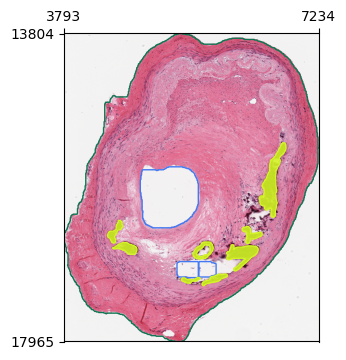

In [20]:
v.set_tissue_id(0)
v.show()

<Axes: >

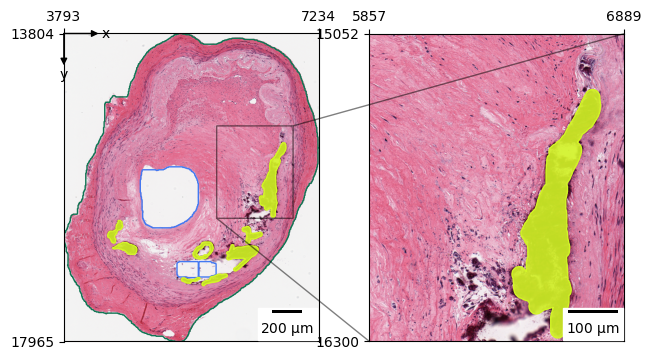

In [21]:
v.add_zoom(0.6, 0.9, 0.3, 0.6)
v.add_scalebar()
v.mark_origin()
v.show()

To summarize, you will have the following code

In [22]:
v = zs.pl.WSIViewer(wsi)
v.add_image()
v.add_contours("tissues")
v.add_polygons("annotations")
v.set_tissue_id(0)
v.add_zoom(0.6, 0.9, 0.3, 0.6)
v.add_scalebar()
v.mark_origin()

If we don't call the `.show()` method, nothing will happen. The plotting will be lazily evaluated.

Now let's call the `.show()` to render the final image.

<Axes: >

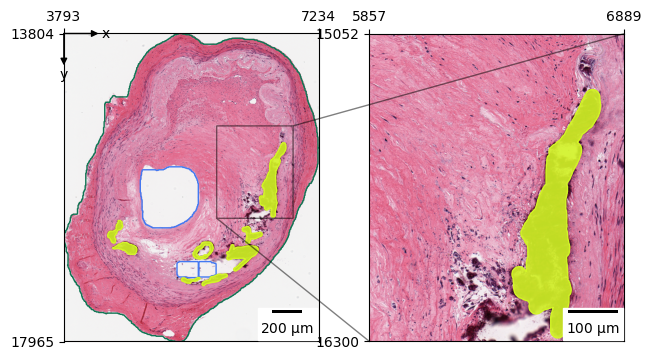

In [23]:
v.show()

You can control if an element shoud be displayed in the zoom view.

Here we disabled the display of yellow annotations in the zoom view.

<Axes: >

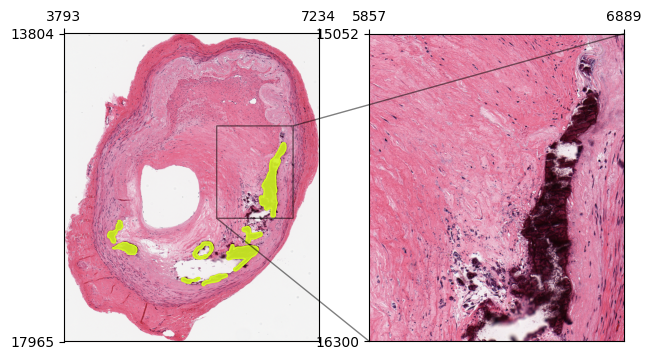

In [24]:
v = zs.pl.WSIViewer(wsi)
v.add_image()
v.add_polygons("annotations", in_zoom=False)
v.set_tissue_id(0)
v.add_zoom(0.6, 0.9, 0.3, 0.6)
v.show()

## Efficient debugging of visualization

The progressive adding components on top of the images gives you finer control on what to visualize.

However, it's not efficient to debug, once you add a component, you cannot delete it.

If you have a large image and you create a new viewer, every time that you want to modify some tiny details, you waste your time on re-computing the image rendering process.

Luckily, we have a solution for this. When you add a component, simply set `cache=False`, and it will only be rendered in the next rendering (only next time you use `show`).

<Axes: >

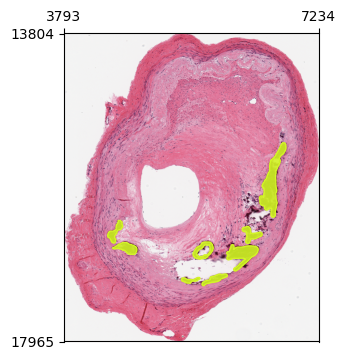

In [25]:
v = zs.pl.WSIViewer(wsi)
v.add_image()
v.add_polygons("annotations", cache=False)
v.set_tissue_id(0)
v.show()

If we called the `.show()` again, the annotation will disappeared.

<Axes: >

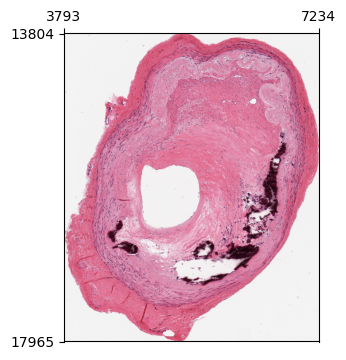

In [26]:
v.show()

In this way, you can easily change color without recomputing the image rendering process.

You may not notice the difference in this example, but if you have a huge WSI. This can make significant difference.

<Axes: >

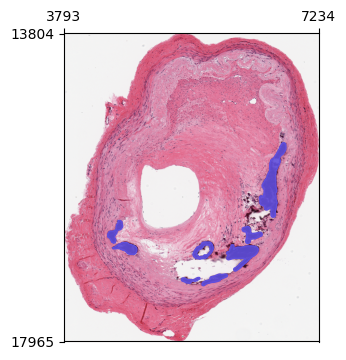

In [27]:
v.add_polygons("annotations", color="#604FDD", cache=False)
v.show()